In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f

In [2]:
check_p_value_uniformity(30,2,1,3,0.01,-1,num_trials=100)

TypeError: merge_inference_F_random_pair_grid() missing 1 required positional argument: 'c2'

In [2]:
def corrected_pdf(grid, log_correction, df1, df2):
    base_pdf = f.pdf(grid,df1,df2)
    #base_pdf= np.zeros_like(grid)
    
    log_correction = np.asarray(log_correction, dtype=float)
    correction = np.exp(log_correction - np.max(log_correction))
    correction[~np.isfinite(correction)] = 0.0
    
    unnorm = base_pdf * correction
    #unnorm =  correction
    z = np.trapezoid(unnorm,grid)
    pdf_corrected = unnorm / z
    
    return pdf_corrected, base_pdf

def plot_corrected_F_pdf(r, pdf_corr,base_pdf, observed=None):
    plt.figure(figsize=(6,4))
    plt.plot(r, pdf_corr, label="Corrected F (pdf)")
    plt.plot(r, base_pdf, label="Uncorrected F (pdf)")
    if observed is not None:
        plt.axvline(observed, ls=":", label=f"obs={observed:.3g}")
    plt.xlabel("r")
    plt.ylabel("density")
    plt.title("Corrected F — PDF")
    plt.legend()
    plt.tight_layout()
    plt.show()

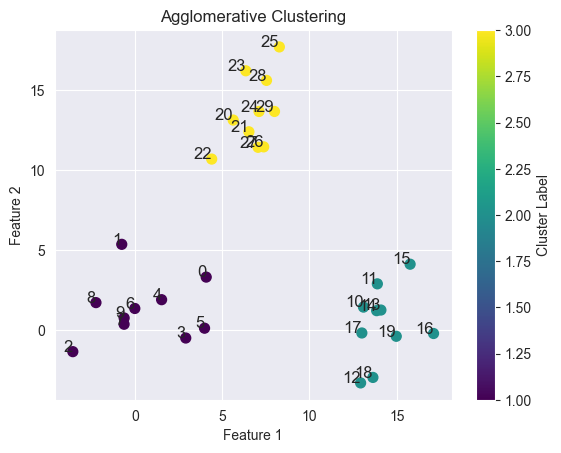

In [3]:
X, y = generate_data_barbers(10,15,2)
plt.scatter(X[:, 0], X[:, 1], s=50, c=y, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [4]:
#X= generate_null_data(30,2,np.zeros(2),1)
n, p = X.shape
model = AgglomerativeClustering(X, tau=0.01, n_clusters=3,linkage="complete")
model.fit(dendrogram=False)

In [5]:
keys = list(model.existing_clusters_log.keys())
clusters = model.existing_clusters_log[keys[-1]]
c1 = model.K_clusters[0]
c2 = model.K_clusters[2]
m = len(c1.points) + len(c2.points)
grid_width = 250
ngrid = 10000
_,_,log_corr =  model.merge_inference_F_random_pair(c1,c2,ngrid=ngrid, grid_width=grid_width)

In [152]:
grid = np.linspace(0.00001, grid_width, num=ngrid)
df1 = p
df2 = (m-2)*p

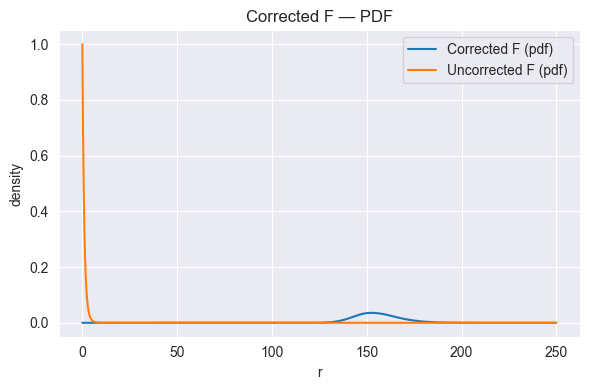

In [153]:
corrected, base = corrected_pdf(grid, log_corr, df1, df2)
plot_corrected_F_pdf(grid, corrected,base)

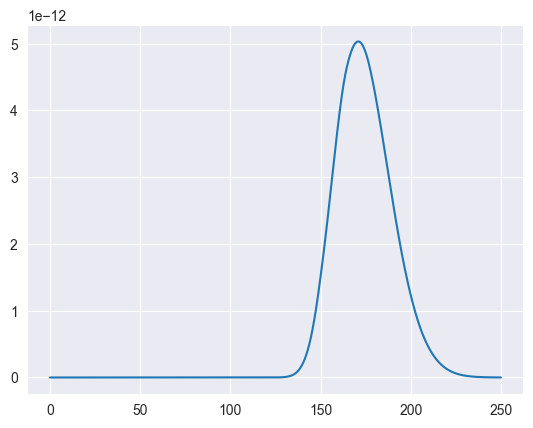

In [154]:
plt.plot(grid, np.exp(log_corr))

np.float64(2.0131119195758942e-260)